In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Goal of the Project

- **Regression**: predict a building's `ENERGYSTARScore` (1–100)
- **Classification**: predict whether the building has a **Pass / Fail** Energy Star score (Pass = score ≥ 75, the EPA's ENERGY STAR certification threshold)

Both exercises can help identify feature importance, informing building owners on how to improve their Energy Star scores.

Consider using probabilities (logistic regression) to define the regression metric

## Understanding the dataset

In [2]:
# Load 2015 Building Energy Benchmarking dataset
df = pd.read_csv("data/2015-building-energy-benchmarking.csv")
df.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,TaxParcelIdentificationNumber,Location,CouncilDistrictCode,Neighborhood,YearBuilt,...,GHGEmissionsIntensity(kgCO2e/ft2),DefaultData,Comment,ComplianceStatus,Outlier,2010 Census Tracts,Seattle Police Department Micro Community Policing Plan Areas,City Council Districts,SPD Beats,Zip Codes
0,1,2015,NonResidential,Hotel,MAYFLOWER PARK HOTEL,659000030,"{'latitude': '47.61219025', 'longitude': '-122...",7,DOWNTOWN,1927,...,2.64,No,NaN,Compliant,NaN,NaN,14.0,NaN,31.0,18081
1,2,2015,NonResidential,Hotel,PARAMOUNT HOTEL,659000220,"{'latitude': '47.61310583', 'longitude': '-122...",7,DOWNTOWN,1996,...,2.38,No,NaN,Compliant,NaN,NaN,14.0,NaN,31.0,18081
2,3,2015,NonResidential,Hotel,WESTIN HOTEL,659000475,"{'latitude': '47.61334897', 'longitude': '-122...",7,DOWNTOWN,1969,...,1.92,Yes,NaN,Compliant,NaN,NaN,56.0,NaN,31.0,18081
3,5,2015,NonResidential,Hotel,HOTEL MAX,659000640,"{'latitude': '47.61421585', 'longitude': '-122...",7,DOWNTOWN,1926,...,31.38,No,NaN,Compliant,High Outlier,NaN,56.0,NaN,31.0,18081
4,8,2015,NonResidential,Hotel,WARWICK SEATTLE HOTEL,659000970,"{'latitude': '47.6137544', 'longitude': '-122....",7,DOWNTOWN,1980,...,4.02,No,NaN,Compliant,NaN,NaN,56.0,NaN,31.0,19576


In [3]:
# Dataset size
print('Shape of dataset:', df.shape)

# Visualize column data types and percent of missing values
overview = pd.DataFrame({
    'dtype': df.dtypes,
    '%_missing': (df.isna().mean() * 100).round(2),
})
overview

Shape of dataset: (3340, 47)


,dtype,%_missing
OSEBuildingID,int64,0.00
DataYear,int64,0.00
BuildingType,object,0.00
PrimaryPropertyType,object,0.00
PropertyName,object,0.00
TaxParcelIdentificationNumber,object,0.06
Location,object,0.00
CouncilDistrictCode,int64,0.00
Neighborhood,object,0.00
YearBuilt,int64,0.00


In [4]:
# Visualize location column to understand how to handle
df['Location']

0       {'latitude': '47.61219025', 'longitude': '-122...
1       {'latitude': '47.61310583', 'longitude': '-122...
2       {'latitude': '47.61334897', 'longitude': '-122...
3       {'latitude': '47.61421585', 'longitude': '-122...
4       {'latitude': '47.6137544', 'longitude': '-122....
                              ...                        
3335    {'latitude': '47.59950256', 'longitude': '-122...
3336    {'latitude': '47.65752471', 'longitude': '-122...
3337    {'latitude': '47.61649845', 'longitude': '-122...
3338    {'latitude': '47.68396954', 'longitude': '-122...
3339    {'latitude': '47.68396954', 'longitude': '-122...
Name: Location, Length: 3340, dtype: object

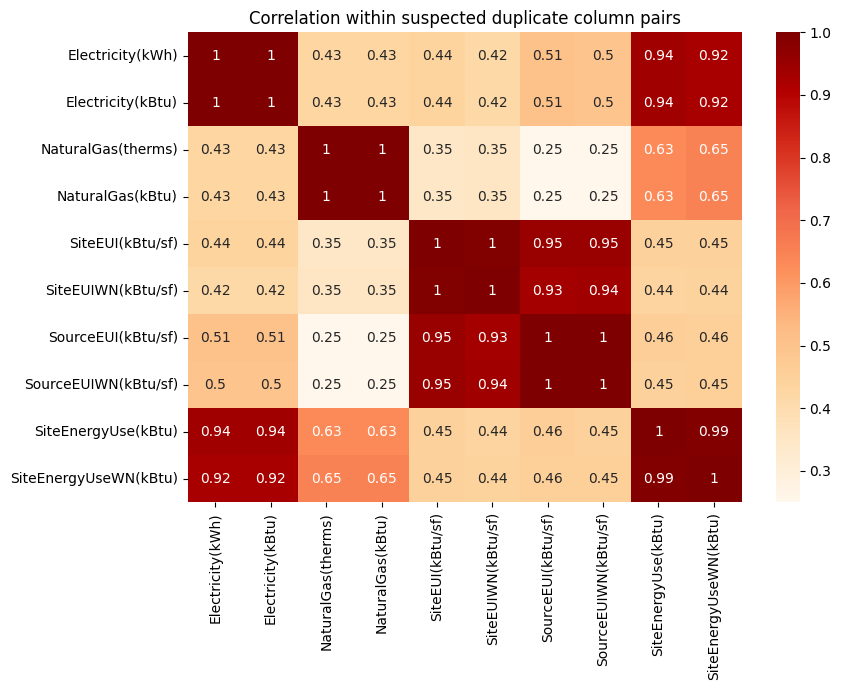

In [5]:
# Noting potential duplicate energy columns (different units)
# Verify correlation for dropping
correlation_check = [
    'Electricity(kWh)',    'Electricity(kBtu)',
    'NaturalGas(therms)',  'NaturalGas(kBtu)',
    'SiteEUI(kBtu/sf)',    'SiteEUIWN(kBtu/sf)',
    'SourceEUI(kBtu/sf)',  'SourceEUIWN(kBtu/sf)',
    'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)',
]

plt.figure(figsize=(9, 7))
sns.heatmap(df[correlation_check].corr(), annot=True, cmap='OrRd')
plt.title('Correlation within suspected duplicate column pairs')
plt.tight_layout()
plt.show()

## Preprocessing

1. Drop high-missing, identifier, and redundant columns
2. Clean remaining columns:
    - Split `Location` into `latitude` / `longitude`
    - Strip whitespace
3. Clean rows:
    - Remove outliers
    - Remove missing target rows
4. Impute the remaining missing values
5. Engineer derived variables (building age, the Pass/Fail target)
6. EDA — distributions and correlations
7. Encode categoricals and note scaling

### Drop high-missing, identifier, and duplicate columns

Groups of columns that carry no predictive value and are removed:

- Mostly empty (>50% missing): 9/47 columns dropped
- Identifiers: building IDs, names, zipcode, tax parcel ID, and arbitrary administrative codes (police beats, council district code, compliance status)
- Duplicates: electricity in kWh (kept in kBtu), natural gas in therms (kept in kBtu), and the weather-normalised copies of the EUI / energy use columns
 - Other useless columns: the constant `DataYear` (we are only looking at 2015 data)

In [6]:
# Outlier column is missing >50% so it will be dropped
# Store the outlier flag before dropping, so flagged rows can be removed later
outlier_flag = df['Outlier'].notna()

# Drop columns that are >50% missing
df = df.dropna(axis=1, thresh=df.shape[0] * 0.50)

# Drop identifiers
identifier_cols = [
    'OSEBuildingID', 'PropertyName', 'TaxParcelIdentificationNumber',
    'ComplianceStatus', 'DefaultData', 'ListOfAllPropertyUseTypes',
    'LargestPropertyUseType', 'CouncilDistrictCode', 'Zip Codes', 'SPD Beats',
    'Seattle Police Department Micro Community Policing Plan Areas',
]

# Drop duplicates
duplicate_cols = [
    'Electricity(kWh)', 'NaturalGas(therms)', 'SiteEUIWN(kBtu/sf)', 
    'SourceEUIWN(kBtu/sf)', 'SiteEnergyUseWN(kBtu)',
]

constant_cols = ['DataYear']

df = df.drop(columns=[c for c in identifier_cols + duplicate_cols + constant_cols if c in df.columns])

print(f'\nShape after dropping columns: {df.shape}')

# Display remaining columns and percent missing
print("\nPercent missing:")
df.isna().mean().round(2) * 100


Shape after dropping columns: (3340, 21)

Percent missing:


BuildingType                          0.0
PrimaryPropertyType                   0.0
Location                              0.0
Neighborhood                          0.0
YearBuilt                             0.0
NumberofBuildings                     0.0
NumberofFloors                        0.0
PropertyGFATotal                      0.0
PropertyGFAParking                    0.0
PropertyGFABuilding(s)                0.0
LargestPropertyUseTypeGFA             4.0
ENERGYSTARScore                      23.0
SiteEUI(kBtu/sf)                      0.0
SourceEUI(kBtu/sf)                    0.0
SiteEnergyUse(kBtu)                   0.0
SteamUse(kBtu)                        0.0
Electricity(kBtu)                     0.0
NaturalGas(kBtu)                      0.0
OtherFuelUse(kBtu)                    0.0
GHGEmissions(MetricTonsCO2e)          0.0
GHGEmissionsIntensity(kgCO2e/ft2)     0.0
dtype: float64

In [7]:
import numpy as np
import ast

# The Location column holds a stringified Python dict
# ast.literal_eval turns each string back into a real dict, then json_normalize expands those dicts into columns
locs = pd.json_normalize(df['Location'].apply(ast.literal_eval))
df[['latitude', 'longitude']] = locs[['latitude', 'longitude']].astype(float)

# The raw Location column can now be dropped
df = df.drop(columns='Location')

df[['latitude', 'longitude']]

,latitude,longitude
0,47.612190,-122.337997
1,47.613106,-122.333358
2,47.613349,-122.337699
3,47.614216,-122.336609
4,47.613754,-122.340924
...,...,...
3335,47.599503,-122.320343
3336,47.657525,-122.316016
3337,47.616498,-122.337708
3338,47.683970,-122.287409


In [8]:
# Clean remaining text columns (strip whitespace)
text_cols = df.select_dtypes(include='object').columns
df[text_cols] = df[text_cols].apply(lambda s: s.str.strip())

### Handle the target

`ENERGYSTARScore` is the regression target, so rows where it is missing (~23%) cannot be used for training. These rows will be dropped, along with rows flagged as outliers and any rows with impossible values (e.g., zero or negative energy use).

In [9]:
# Visualize statistics of numeric rows to better understand any processing required on rows
df.select_dtypes('number').describe()

,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,PropertyGFAParking,PropertyGFABuilding(s),LargestPropertyUseTypeGFA,ENERGYSTARScore,SiteEUI(kBtu/sf),SourceEUI(kBtu/sf),SiteEnergyUse(kBtu),SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),OtherFuelUse(kBtu),GHGEmissions(MetricTonsCO2e),GHGEmissionsIntensity(kgCO2e/ft2),latitude,longitude
count,3340.000000,3340.000000,3332.000000,3.340000e+03,3340.000000,3.340000e+03,3.204000e+03,2560.000000,3330.000000,3330.000000,3.330000e+03,3.330000e+03,3.330000e+03,3.330000e+03,3.330000e+03,3330.000000,3330.000000,3340.000000,3340.000000
mean,1967.624850,1.035629,4.682173,9.077289e+04,11054.032335,7.971886e+04,7.488154e+04,67.894141,53.626126,132.779730,4.983106e+06,2.502851e+05,3.473209e+06,1.253304e+06,7.142301e+03,110.094102,0.985339,47.624091,-122.335013
std,32.949847,0.784463,5.458460,1.493058e+05,35296.330507,1.292314e+05,1.236249e+05,27.154057,53.893311,131.943223,1.375330e+07,3.481900e+06,9.519639e+06,4.415142e+06,1.962790e+05,409.450179,1.637172,0.047924,0.027169
min,1900.000000,1.000000,0.000000,2.000000e+04,-3.000000,-5.055000e+04,5.872000e+03,1.000000,0.000000,-2.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,47.499331,-122.413996
25%,1947.000000,1.000000,2.000000,2.848700e+04,0.000000,2.668300e+04,2.500000e+04,51.750000,27.300000,73.500000,9.139300e+05,0.000000e+00,6.363322e+05,0.000000e+00,0.000000e+00,9.265000,0.080000,47.599836,-122.350568
50%,1973.000000,1.000000,4.000000,4.385500e+04,0.000000,4.132600e+04,3.900000e+04,76.000000,37.400000,95.000000,1.776219e+06,0.000000e+00,1.160236e+06,2.945770e+05,0.000000e+00,32.740000,0.460000,47.618496,-122.332712
75%,1996.000000,1.000000,5.000000,8.842800e+04,4304.250000,7.872600e+04,7.206750e+04,90.000000,59.875000,143.900000,4.044277e+06,0.000000e+00,2.750847e+06,1.115366e+06,0.000000e+00,88.642500,1.180000,47.657223,-122.319898
max,2015.000000,39.000000,99.000000,2.200000e+06,512608.000000,2.200000e+06,1.719643e+06,100.000000,800.600000,2511.100000,2.958126e+08,1.278697e+08,2.847263e+08,1.364484e+08,8.269669e+06,11824.890000,31.380000,47.733811,-122.220470


In [10]:
original_rows = len(df)

# Drop city-flagged outliers
df = df[~outlier_flag]
n_rows = len(df)
print(f'Dropped {original_rows - n_rows} city-flagged outlier rows')

# Drop rows with no target (can't train on a missing label)
df = df[df['ENERGYSTARScore'].notna()]
new_rows = len(df)
print(f'Dropped {n_rows - new_rows} rows with missing ENERGYSTARScore')

# Drop physically impossible values (zero or negative physical factors / energy use)
df = df[
    (df['PropertyGFATotal'] > 0) &
    (df['PropertyGFABuilding(s)'] >= 0) &
    (df['PropertyGFAParking'] >= 0) &
    (df['SiteEUI(kBtu/sf)'] >= 0) &
    (df['SourceEUI(kBtu/sf)'] >= 0) &
    (df['SiteEnergyUse(kBtu)'] >= 0)
]
print(f'Dropped {new_rows - len(df)} rows with impossible values')

print(f'\nFinal row count: {len(df)}')

Dropped 84 city-flagged outlier rows
Dropped 765 rows with missing ENERGYSTARScore
Dropped 3 rows with impossible values

Final row count: 2488


### Impute remaining missing values

In [11]:
df.isna().sum()

BuildingType                           0
PrimaryPropertyType                    0
Neighborhood                           0
YearBuilt                              0
NumberofBuildings                      0
NumberofFloors                         3
PropertyGFATotal                       0
PropertyGFAParking                     0
PropertyGFABuilding(s)                 0
LargestPropertyUseTypeGFA            107
ENERGYSTARScore                        0
SiteEUI(kBtu/sf)                       0
SourceEUI(kBtu/sf)                     0
SiteEnergyUse(kBtu)                    0
SteamUse(kBtu)                         0
Electricity(kBtu)                      0
NaturalGas(kBtu)                       0
OtherFuelUse(kBtu)                     0
GHGEmissions(MetricTonsCO2e)           0
GHGEmissionsIntensity(kgCO2e/ft2)      0
latitude                               0
longitude                              0
dtype: int64

In [12]:
# Numeric feature columns to impute (exclude the regression target)
num_cols = df.select_dtypes(include='number').columns.difference(['ENERGYSTARScore'])

# Group-median imputation by PrimaryPropertyType
df[num_cols] = df.groupby('PrimaryPropertyType')[num_cols].transform(lambda s: s.fillna(s.median()))

# Global-median fallback for any group that had no observations at all
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

df.isna().sum()

BuildingType                         0
PrimaryPropertyType                  0
Neighborhood                         0
YearBuilt                            0
NumberofBuildings                    0
NumberofFloors                       0
PropertyGFATotal                     0
PropertyGFAParking                   0
PropertyGFABuilding(s)               0
LargestPropertyUseTypeGFA            0
ENERGYSTARScore                      0
SiteEUI(kBtu/sf)                     0
SourceEUI(kBtu/sf)                   0
SiteEnergyUse(kBtu)                  0
SteamUse(kBtu)                       0
Electricity(kBtu)                    0
NaturalGas(kBtu)                     0
OtherFuelUse(kBtu)                   0
GHGEmissions(MetricTonsCO2e)         0
GHGEmissionsIntensity(kgCO2e/ft2)    0
latitude                             0
longitude                            0
dtype: int64

### Feature engineering

- Building age is more interpretable than year built: `building_age` = 2015 − `YearBuilt`
- Parking ratio can be more valuable than raw parking GFA due to scale
- Classification target (pass/fail) should be derived from `ENERGYSTARScore` (pass >= 75, as per the EPA's official threshold for ENERGY STAR certification)

In [13]:
# Building age (the benchmarking data year is 2015)
df['building_age'] = 2015 - df['YearBuilt']
df = df.drop(columns='YearBuilt')

# Ratio of gross floor area that is parking 
df['parking_ratio'] = df['PropertyGFAParking'] / df['PropertyGFATotal']

# Classification target: Pass / Fail at the ENERGY STAR certification threshold (>= 75)
PASS_THRESHOLD = 75
df['ENERGYSTARCertification'] = np.where(df['ENERGYSTARScore'] >= PASS_THRESHOLD, 'Pass', 'Fail')

# Visualize class balance
(df['ENERGYSTARCertification'].value_counts(normalize=True) * 100).round(1)

ENERGYSTARCertification
Pass    51.2
Fail    48.8
Name: proportion, dtype: float64

## EDA

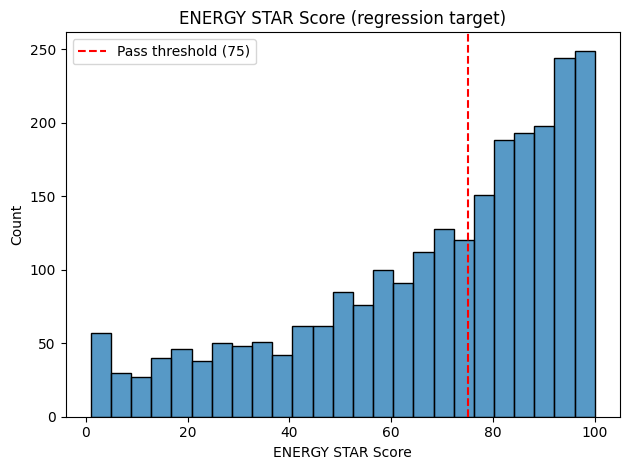

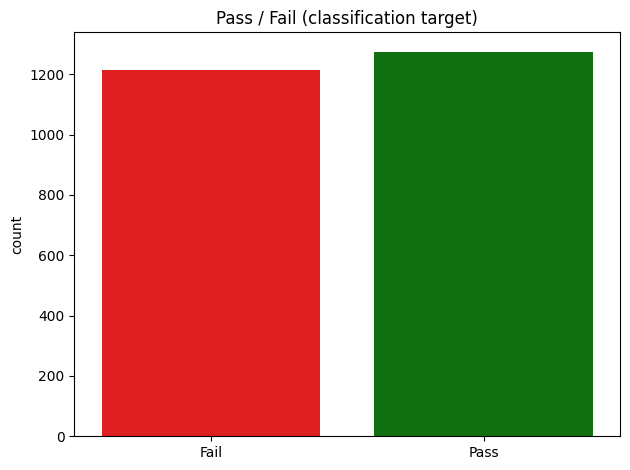

In [14]:
# Regression target: ENERGY STAR Score distribution
sns.histplot(df['ENERGYSTARScore'], bins=25)
plt.axvline(PASS_THRESHOLD, color='red', linestyle='--', label=f'Pass threshold ({PASS_THRESHOLD})')
plt.title('ENERGY STAR Score (regression target)')
plt.xlabel('ENERGY STAR Score')
plt.legend()
plt.tight_layout()
plt.show()

# Classification target: Pass / Fail balance
sns.countplot(x='ENERGYSTARCertification', data=df, hue='ENERGYSTARCertification', palette={'Fail': 'red', 'Pass': 'green'})
plt.title('Pass / Fail (classification target)')
plt.xlabel('')
plt.tight_layout()
plt.show()

In [15]:
# Visualize skew
num = df.select_dtypes('number').drop(columns=['ENERGYSTARScore'])

num.skew().round(1).sort_values(ascending=False)

OtherFuelUse(kBtu)                   35.3
NumberofBuildings                    30.1
SteamUse(kBtu)                       28.9
NaturalGas(kBtu)                     19.7
GHGEmissions(MetricTonsCO2e)         19.1
Electricity(kBtu)                    14.6
SiteEnergyUse(kBtu)                  13.7
SourceEUI(kBtu/sf)                    8.5
LargestPropertyUseTypeGFA             6.1
SiteEUI(kBtu/sf)                      6.1
PropertyGFAParking                    5.8
PropertyGFABuilding(s)                5.8
NumberofFloors                        5.7
PropertyGFATotal                      5.6
GHGEmissionsIntensity(kgCO2e/ft2)     3.1
parking_ratio                         1.8
building_age                          0.6
latitude                              0.1
longitude                            -0.1
dtype: float64

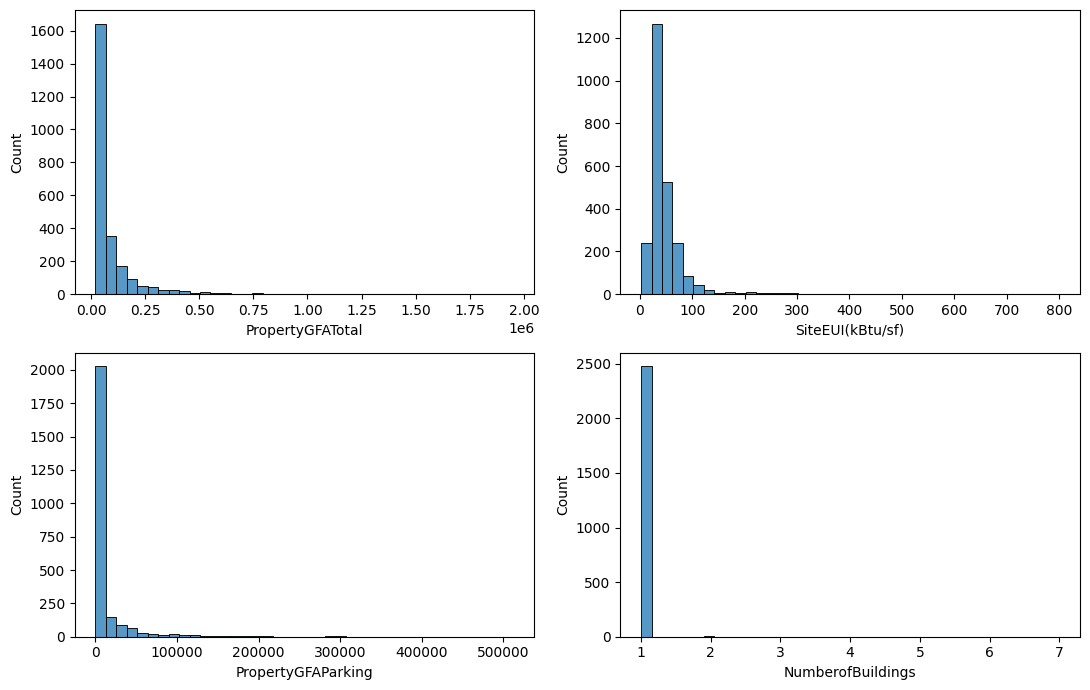

In [16]:
# Plot some of the skewed features to identify future transformations required
skewed = ['PropertyGFATotal', 'SiteEUI(kBtu/sf)', 'PropertyGFAParking', 'NumberofBuildings']

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, col in zip(axes.flatten(), skewed):
    sns.histplot(df[col], bins=40, ax=ax)
plt.tight_layout()
plt.show()

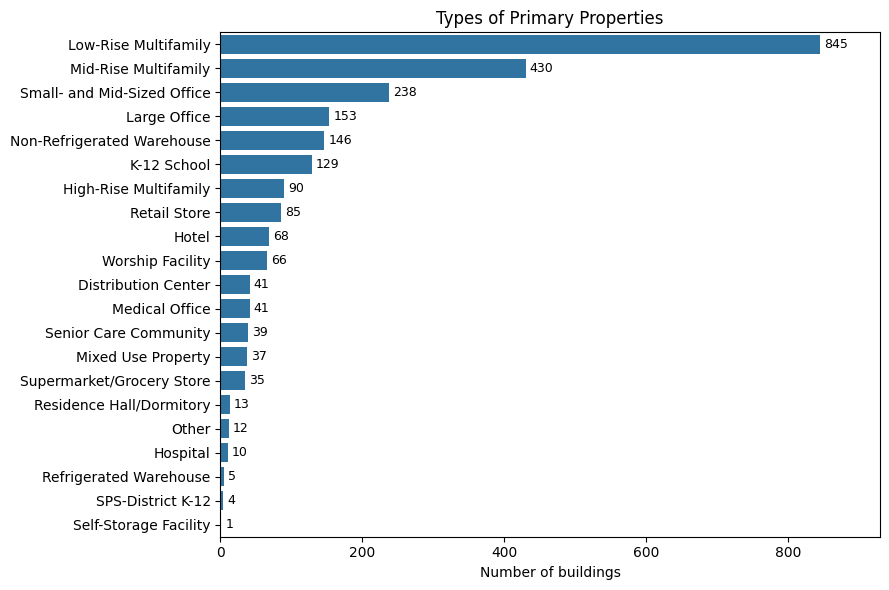

In [17]:
# Visualize PrimaryPropertyType frequencies to see the distribution of categories
counts = df['PrimaryPropertyType'].value_counts()
plt.figure(figsize=(9,6))
ax = sns.barplot(x=counts.values, y=counts.index)

# Value label at the end of each bar
for container in ax.containers:
    ax.bar_label(container, padding=3, fontsize=9)
ax.margins(x=0.1)  # extra room so the labels aren't clipped

plt.xlabel('Number of buildings')
plt.ylabel('')
plt.title('Types of Primary Properties')
plt.tight_layout()
plt.show()

In [366]:
# Collapse rare PrimaryPropertyType categories (< 15 buildings) into 'Other' to avoid risk of imbalanced train/test split
RARE_THRESHOLD = 15
counts = df['PrimaryPropertyType'].value_counts()
rare_types = counts.index[counts < RARE_THRESHOLD]

# Reassign the rare categories to 'Other'
df.loc[df['PrimaryPropertyType'].isin(rare_types), 'PrimaryPropertyType'] = 'Other'

df['PrimaryPropertyType'].value_counts()

PrimaryPropertyType
Low-Rise Multifamily           845
Mid-Rise Multifamily           430
Small- and Mid-Sized Office    238
Large Office                   153
Non-Refrigerated Warehouse     146
K-12 School                    129
High-Rise Multifamily           90
Retail Store                    85
Hotel                           68
Worship Facility                66
Other                           45
Distribution Center             41
Medical Office                  41
Senior Care Community           39
Mixed Use Property              37
Supermarket/Grocery Store       35
Name: count, dtype: int64

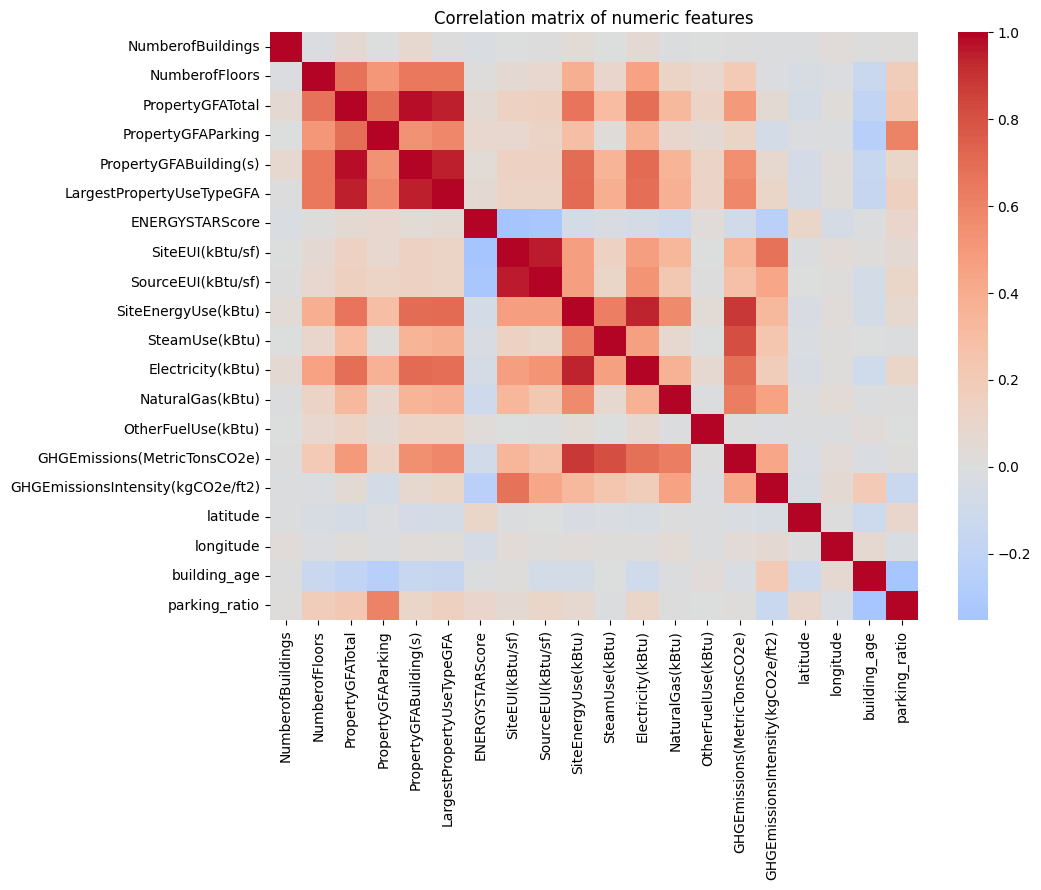

Correlation with ENERGYSTARScore:
SiteEUI(kBtu/sf)                    -0.352734
SourceEUI(kBtu/sf)                  -0.339566
GHGEmissionsIntensity(kgCO2e/ft2)   -0.233007
NaturalGas(kBtu)                    -0.099446
GHGEmissions(MetricTonsCO2e)        -0.083668
SiteEnergyUse(kBtu)                 -0.076705
longitude                           -0.056611
Electricity(kBtu)                   -0.054580
SteamUse(kBtu)                      -0.033658
NumberofBuildings                   -0.024997
building_age                        -0.010967
NumberofFloors                       0.013227
OtherFuelUse(kBtu)                   0.024150
PropertyGFABuilding(s)               0.045117
LargestPropertyUseTypeGFA            0.054963
PropertyGFATotal                     0.058207
PropertyGFAParking                   0.084144
parking_ratio                        0.096554
latitude                             0.103177
Name: ENERGYSTARScore, dtype: float64


In [ ]:
# Visualize correlation among numeric features and the regression target
num_for_corr = df.select_dtypes(include='number')

plt.figure(figsize=(11, 9))
sns.heatmap(num_for_corr.corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Correlation matrix of numeric features')
plt.tight_layout()
plt.show()

print('Correlation with ENERGYSTARScore:')
print(num_for_corr.corr()['ENERGYSTARScore'].drop('ENERGYSTARScore').sort_values())